# Train LightGB

### Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import datetime, timedelta
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from typing import cast
import numpy.typing as npt

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Required to avoid import bugs
root_path = Path.cwd().parent.parent
sys.path.append(str(root_path))

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    stream=sys.stdout # Indispensable pour voir les logs sous la cellule
)

# personalized imports
from scripts.data_preparation.get_main import main_query_db
from scripts.data_preparation.preprocessed import main_preprocessed
from scripts.data_preparation.utils.progress_bar import TqdmCallback

d:\INSA_Lyon\2nd_semester\M1_Challenge_St_Exupery\.venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
d:\INSA_Lyon\2nd_semester\M1_Challenge_St_Exupery\.venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


### Global variables

In [2]:
root = Path(os.getcwd()).parent.parent
DATA_FOLDER_PATH = os.path.join(root, "data")

DATASET_PATH_PAX = os.path.join(DATA_FOLDER_PATH, "main_preprocessed.csv")
DATASET_PATH_PHMR = os.path.join(DATA_FOLDER_PATH, "main_preprocessed_PHMR.csv")

MODEL_FOLDER_PATH = os.path.join(root, "models")
MODEL_FILENAME = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor.pkl")
MODEL_FILENAME_PHMR = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor_PHMR.pkl")

TARGET = ["NbPaxTotal", "FarmsNbPaxPHMR"]

# Today & tomorrow
now = datetime.now()
today = pd.Timestamp(now.date())
yesterday =  pd.Timestamp(today - timedelta(days=1))
two_days_ago = pd.Timestamp(yesterday - timedelta(days=1))
tomorrow = pd.Timestamp(today + timedelta(days=1))
two_days_later = pd.Timestamp(tomorrow + timedelta(days=1))

# LIMIT_DATE_TRAIN = two_days_ago
# LIMIT_DATE_VALID = today
# LIMIT_DATE_TEST = two_days_later


LIMIT_DATE_TRAIN = pd.Timestamp("2026-03-27")
LIMIT_DATE_VALID = pd.Timestamp("2026-03-28")
LIMIT_DATE_TEST = pd.Timestamp("2026-03-30")


PREDICTIONS_FILENAME = os.path.join(DATA_FOLDER_PATH, f"prediction_{LIMIT_DATE_VALID.strftime('%Y-%m-%d')}.csv")

### Load and prepare data

**Feature selection:** Done during the database querying using BigQuery

We decide to keep only the features available to make prediction, avoiding data leakage. It is impossible to use future data to make predictions, so we decide to exclude the feature related to future data. (ex: 'FarmNbPaxTotal' designed the LABEL obtained witht the intern Aiport data collection system - this feature is not available to make prediction).
We decide to keep all the features, in particular fancy ones like 'IdBusContactType' or 'OperatorOACICodeNormalized', becausse they may impact the model performances.

<br>

**Preprocessing:** The preprocessing is divided into X parts:
- The feature engineering: the main work is done here. We choose to add **date related features**, by slicing the 'LTScheduledDatetime' column into many (year, month, day, hour and minutes). We also decide to use **cyclical encoding** on those features to help the model capture  the time proximity (ex: 11.45 PM is close to 1.00 AM). Finally we decide to compute statistics features based on historic data of the label (**rolling statistics, lag statistics, trend statistics, cross-feature, momentum calculation**). For more details, cf. `scripts/data_preparation/utils/main/add_features.py`.

- The type management: Some columns must be encoded as specific types to allow model training (LightGBM). For example dates must be encoded as `string` instead of `datetime`. Additionally, numerous categorical values to encode as `category`. This last part is done later in the code, after the train / validation / test split, to avoid data leakage. If the category encoding is done before the split, the model will know data from the test set (future data).


**Note:** Around  minutes of execution time.

In [ ]:
# Load the preprocessed data - or build the needed df.
if os.path.exists(DATASET_PATH_PAX) and os.path.exists(DATASET_PATH_PHMR) : 
    logging.info('Loading preprocessed file ...')
    df = pd.read_csv(DATASET_PATH_PAX, encoding='utf-8')
    df_PHMR = pd.read_csv(DATASET_PATH_PHMR, encoding='utf-8')
else:
    ### Full pipeline
    # Query the data
    # Using BigQuery.
    logging.info("Querying ...")
    #main_query_db()
    logging.info("Preprocessing ...")
    df, df_PHMR = main_preprocessed(with_holidays=False)

Querying ...
Preprocessing ...
Data split - PHMR management
Add of date related features
Processing features for group: global
Processing features for group: SysTerminal
Processing features for group: IdAircraftType
Processing features for group: FlightNumberNormalized


In [10]:
print(df.shape)

(365012, 390)


#### Data splitting

Split the data into 3 main parts:
- **train:** Used to train our model
- **validation:** Used to monitor and tune model performance during the training phase
- **test:** Used to evaluate final performance once training is complete. 

This split must **strictly follow chronological order**. Since the temporality of the data is the most critical factor in this project, using random shuffling would be a mistake. The separation is therefore performed using specific dates as filtering criteria for the main dataset.

Additionally, **PHMR data** must be **split separately**, as the PHMR model and the main model are trained using different data sources.

In [11]:
### PAX
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")
print(f"Test set: {len(test_df)} rows / From {test_df['LTScheduledDatetime'].min()} to {test_df['LTScheduledDatetime'].max()}\n")

### PHMR
df_PHMR['LTScheduledDatetime'] = pd.to_datetime(df_PHMR['LTScheduledDatetime'])

train_df_PHMR = df_PHMR[df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df_PHMR['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set PHMR: {len(train_df_PHMR)} rows / From {train_df_PHMR['LTScheduledDatetime'].min()} to {train_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Valid set PHMR: {len(valid_df_PHMR)} rows / From {valid_df_PHMR['LTScheduledDatetime'].min()} to {valid_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Test set PHMR: {len(test_df_PHMR)} rows / From {test_df_PHMR['LTScheduledDatetime'].min()} to {test_df_PHMR['LTScheduledDatetime'].max()}")


Train set: 308871 rows / From 2023-01-01 00:05:00 to 2026-03-26 23:45:00
Valid set: 284 rows / From 2026-03-27 04:45:00 to 2026-03-27 23:55:00
Test set: 510 rows / From 2026-03-28 05:10:00 to 2026-03-29 23:50:00

Train set PHMR: 308871 rows / From 2023-01-01 00:05:00 to 2026-03-26 23:45:00
Valid set PHMR: 284 rows / From 2026-03-27 04:45:00 to 2026-03-27 23:55:00
Test set PHMR: 510 rows / From 2026-03-28 05:10:00 to 2026-03-29 23:50:00


#### Last preprocess

- Datetime conversion
- Category encoding
- Remove the label of training datasets.

In [12]:
### PAX
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df['LTScheduledDatetime'] = train_df['LTScheduledDatetime'].astype(str)
valid_df['LTScheduledDatetime'] = valid_df['LTScheduledDatetime'].astype(str)
test_df['LTScheduledDatetime'] = test_df['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train = train_df.drop(columns=[TARGET[0]])
y_train = train_df[TARGET[0]]
X_valid = valid_df.drop(columns=[TARGET[0]])
y_valid = valid_df[TARGET[0]]
X_test = test_df.drop(columns=[TARGET[0]])

# Convert to categorical the needed features.
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')
    X_test[col] = X_test[col].astype('category')


print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_valid: {X_valid.shape}")
print(f"Shape X_test: {X_test.shape}\n")

### PHMR
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df_PHMR['LTScheduledDatetime'] = train_df_PHMR['LTScheduledDatetime'].astype(str)
valid_df_PHMR['LTScheduledDatetime'] = valid_df_PHMR['LTScheduledDatetime'].astype(str)
test_df_PHMR['LTScheduledDatetime'] = test_df_PHMR['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train_PHMR = train_df_PHMR.drop(columns=[TARGET[1]])
y_train_PHMR = train_df_PHMR[TARGET[1]]
X_valid_PHMR = valid_df_PHMR.drop(columns=[TARGET[1]])
y_valid_PHMR = valid_df_PHMR[TARGET[1]]
X_test_PHMR = test_df_PHMR.drop(columns=[TARGET[1]])

# Convert to categorical the needed features.
for col in X_train_PHMR.select_dtypes(include=['object']).columns:
    X_train_PHMR[col] = X_train_PHMR[col].astype('category')
    X_valid_PHMR[col] = X_valid_PHMR[col].astype('category')
    X_test_PHMR[col] = X_test_PHMR[col].astype('category')


print(f"Shape X_train_PHMR: {X_train_PHMR.shape}")
print(f"Shape X_valid_PHMR: {X_valid_PHMR.shape}")
print(f"Shape X_test_PHMR: {X_test_PHMR.shape}")


Shape X_train: (308871, 389)
Shape X_valid: (284, 389)
Shape X_test: (510, 389)

Shape X_train_PHMR: (308871, 30)
Shape X_valid_PHMR: (284, 30)
Shape X_test_PHMR: (510, 30)


### Train or Load the model

The model we decide to use is LightGBM. This was an empirical choice explain later in our report.

#### 1. Pax train

In [14]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME) :
    model_Pax = joblib.load(MODEL_FILENAME)
    logging.info("Pax model load successfuly.")

else : 
    n_estimators = 10000

    model_Pax = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_Pax.fit(
            X_train, y_train,         
            eval_set=[(X_valid, y_valid)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_Pax, MODEL_FILENAME)

LightGBM training:   0%|          | 0/10000 [00:00<?, ?it/s]

LightGBM training:   0%|          | 2/10000 [00:06<7:56:45,  2.86s/it, mae=58.5466] 

Training until validation scores don't improve for 100 rounds


LightGBM training:  12%|█▏        | 1157/10000 [03:35<20:01,  7.36it/s, mae=10.8205]  

Early stopping, best iteration is:
[1057]	valid_0's l1: 10.8225	valid_0's l2: 260.111


LightGBM training:  12%|█▏        | 1157/10000 [03:36<27:38,  5.33it/s, mae=10.8205]


#### 2. PHMR Train

In [15]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME_PHMR) :  
    model_PHMR = joblib.load(MODEL_FILENAME_PHMR)
    logging.info("PHMR model load successfuly.")

else : 
    n_estimators = 10000

    model_PHMR = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_PHMR.fit(
            X_train_PHMR, y_train_PHMR,         
            eval_set=[(X_valid_PHMR, y_valid_PHMR)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_PHMR, MODEL_FILENAME_PHMR)

LightGBM training:   0%|          | 12/10000 [00:00<13:22, 12.44it/s, mae=0.9143] 

Training until validation scores don't improve for 100 rounds


LightGBM training:   8%|▊         | 810/10000 [00:17<03:26, 44.53it/s, mae=0.3449]

Early stopping, best iteration is:
[710]	valid_0's l1: 0.345439	valid_0's l2: 1.48105


LightGBM training:   8%|▊         | 810/10000 [00:18<03:24, 44.91it/s, mae=0.3449]


### Prediction and Evaluation

#### Evaluation on the validation dataset

- Total Pax :

In [19]:
predictions = model_Pax.predict(X_valid)
preds_array = cast(npt.NDArray[np.float32], predictions)
predictions = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── Results for Pax model ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for Pax model ──
   MAE : 10.76 passengers
   R²  : 0.9422
   RMSE : 16.12


- PHMR

In [ ]:
predictions_PHMR = model_PHMR.predict(X_valid_PHMR)
preds_array = cast(npt.NDArray[np.float32], predictions_PHMR)
predictions_PHMR = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid_PHMR, predictions_PHMR)
r2 = r2_score(y_valid_PHMR, predictions_PHMR)
rmse = root_mean_squared_error(y_valid_PHMR, predictions_PHMR)

print(f"\n── Results for PHMR models ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for PHMR models ──
   MAE : 0.29 passengers
   R²  : 0.7618
   RMSE : 1.01


#### Predictions

In [20]:
# predictions
predictions_nb_pax = model_Pax.predict(X_test)
preds_nb_pax_array = cast(npt.NDArray[np.float32], predictions_nb_pax)
predictions_nb_pax = np.maximum(0.0, preds_nb_pax_array)
predictions_nb_pax = np.round(predictions_nb_pax)

predictions_phmr_pax = model_PHMR.predict(X_test_PHMR)
preds_phmr_pax = cast(npt.NDArray[np.float32], predictions_phmr_pax)
predictions_phmr_pax = np.maximum(0.0, preds_phmr_pax)
predictions_phmr_pax = np.round(predictions_phmr_pax)

df_final = X_test[['FlightNumberNormalized', 'LTScheduledDatetime']].copy() 
df_final.loc[:, 'PredNbPaxTotal'] = predictions_nb_pax
df_final.loc[:, 'PredFarmsNbPaxPHMR'] = predictions_phmr_pax

df_final.to_csv(PREDICTIONS_FILENAME, encoding = 'utf-8', index=False)

#### Prediction evaluation

On past data, to evaluate or model on test dataset by comparing the real data to predictions.

For PHMR pax, the calculated metrics are not so relevant, due to the low statistical representation of PHMR pax.

In [21]:
def calculate_all_metrics(df, col_pred, col_reel, col_date):
    """
    Calcule le WAPE et le Ratio de prédiction au global, par jour et par heure.
    """
    # 1. S'assurer que la colonne date est au bon format
    df = df.copy()
    df[col_date] = pd.to_datetime(df[col_date])
    df['Jour'] = df[col_date].dt.date
    df['Heure'] = df[col_date].dt.hour

    # --- MÉTRIQUES TOTALES ---
    total_reel = df[col_reel].sum()
    total_pred = df[col_pred].sum()
    
    total_metrics = {
        'WAPE_Global': np.abs(total_pred - total_reel) / total_reel,
        'Pred_Ratio_Global': (total_pred / total_reel) * 100
    }

    # --- Daily ---
    daily_agg = df.groupby('Jour').agg({col_reel: 'sum', col_pred: 'sum'})
    daily_agg['WAPE'] = np.abs(daily_agg[col_pred] - daily_agg[col_reel]) / daily_agg[col_reel]
    daily_agg['Ratio_Pred'] = (daily_agg[col_pred] / daily_agg[col_reel]) * 100

    # --- Hourly ---
    hourly_agg = df.groupby('Heure').agg({col_reel: 'sum', col_pred: 'sum'})
    hourly_agg['WAPE'] = np.abs(hourly_agg[col_pred] - hourly_agg[col_reel]) / hourly_agg[col_reel]
    hourly_agg['Ratio_Pred'] = (hourly_agg[col_pred] / hourly_agg[col_reel]) * 100

    return {
        "Global": total_metrics,
        "Daily": daily_agg.reset_index(),
        "Hourly": hourly_agg.reset_index()
    }



In [22]:
### Build the DataFrame used for predictions evaluation.
RAW_FILENAME = os.path.join(DATA_FOLDER_PATH, "main.csv")

# Load the raw data
raw_data = pd.read_csv(RAW_FILENAME, encoding='utf-8')
raw_data['LTScheduledDatetime'] = pd.to_datetime(raw_data['LTScheduledDatetime'])
raw_data_test = raw_data[(raw_data['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (raw_data['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()
raw_data_test = raw_data_test[["FlightNumberNormalized", "LTScheduledDatetime", "NbPaxTotal", "FarmsNbPaxPHMR"]].copy()

df_final['LTScheduledDatetime'] = pd.to_datetime(df_final['LTScheduledDatetime'])

df_merge = pd.merge(left=raw_data_test, right=df_final, on=["FlightNumberNormalized", "LTScheduledDatetime"], how="left")


In [23]:
# --- Evaluation ---  
# /!\ To run only if we have the labels for the test set (for evaluation...)
results = calculate_all_metrics(df_merge, 'PredNbPaxTotal', 'NbPaxTotal', 'LTScheduledDatetime')
results_PHMR = calculate_all_metrics(df_merge, 'PredFarmsNbPaxPHMR', 'FarmsNbPaxPHMR', 'LTScheduledDatetime')

print("--- Results NbPaxTotal ---")
print(f"WAPE Global: {results['Global']['WAPE_Global']:.2%} - Ratio Global: {results['Global']['Pred_Ratio_Global']:.2f}")
print(results['Daily'].head())
print('\n')
print(results['Hourly'].head())
print('\n')


print("--- Results FarmsNbPaxPHMR ---")
print(f"WAPE Global: {results_PHMR['Global']['WAPE_Global']:.2%} - Ratio Global: {results_PHMR['Global']['Pred_Ratio_Global']:.2f}")
print(results_PHMR['Daily'].head())
print('\n')
print(results_PHMR['Hourly'].head())        # Not relevant.
print('\n')


--- Results NbPaxTotal ---
WAPE Global: 0.32% - Ratio Global: 100.32
         Jour  NbPaxTotal  PredNbPaxTotal      WAPE  Ratio_Pred
0  2026-03-28     31343.0         30773.0  0.018186   98.181412
1  2026-03-29     30562.0         31332.0  0.025195  102.519469


   Heure  NbPaxTotal  PredNbPaxTotal      WAPE  Ratio_Pred
0      0       645.0           623.0  0.034109   96.589147
1      3       164.0           157.0  0.042683   95.731707
2      5        96.0            91.0  0.052083   94.791667
3      6      2933.0          2982.0  0.016706  101.670644
4      7      1590.0          1711.0  0.076101  107.610063


--- Results FarmsNbPaxPHMR ---
WAPE Global: 23.91% - Ratio Global: 76.09
         Jour  FarmsNbPaxPHMR  PredFarmsNbPaxPHMR      WAPE  Ratio_Pred
0  2026-03-28           192.0               161.0  0.161458   83.854167
1  2026-03-29           222.0               154.0  0.306306   69.369369


   Heure  FarmsNbPaxPHMR  PredFarmsNbPaxPHMR      WAPE  Ratio_Pred
0      0             1.

## Analysis

### NbPaxTotal

#### 1. Feature importance

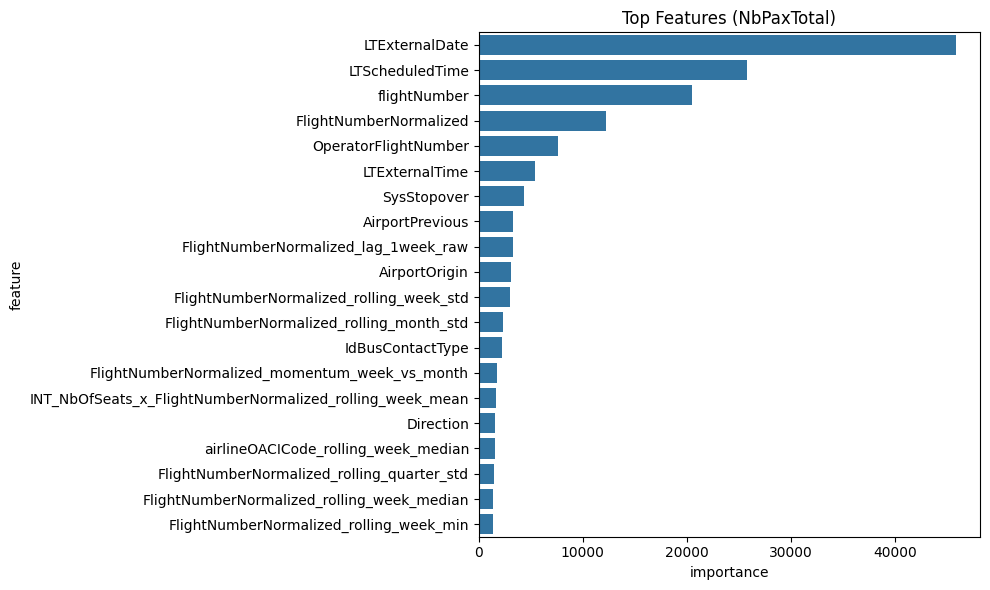

In [24]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_Pax.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_Pax.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### Feature Importance Analysis

Among the top 20 features driving the model's predictions, **date-related strings features** emerge as the most influential. Features associated with **Flight Number** or **Flight ID** also play a critical role in prediction accuracy. 

This suggests that **recurring patterns** within the data are the most effective indicators for predicting passenger counts (Pax). Since Flight IDs and Flight Numbers are repetitive—with the same flight typically operating under the same number daily—the model leverages these identifiers to recognize historical patterns and adjust its forecasts accordingly.

Similarly, features such as `IdAircraftType`, `SysStopover`, `IdBusContactType`, `AirportOrigin`, and `AirportPrevious` serve as key markers that help the model re-identify specific flight rotations or seasonal cycles.

> **Note:** We are also incorporating **cyclical encoding** for temporal data (such as hour of the week or minute) to better capture time-based oscillations.

---

**Historical & Rolling Statistics**

Another essential category of features involves **historical rolling statistics**. For instance, a feature like `FlightNumberNormalized_lag7_win6_min` (calculating the minimum Pax from 7 days ago within a $\pm$ 3-day window, grouped by flight number) allows the model to integrate a **historical perspective** into its current logic.

<br>

**Cross-Features & Dimensional Synergy**

Finally, the model utilizes **cross-features**, such as `INT_NbOfSeats_x_FlightNumberNormalized_lag7_win6_mean`. These interactions help the model capture the relationship between different variables, allowing it to understand how information overlaps across multiple dimensions to improve overall performance.

<br>

**Remark:** Here, there are only the 20 most important variables. Lot of other variables influence the model performances, in particular the added features (rolling, lag, trend, ...) 

#### 2. Prediction VS Reality

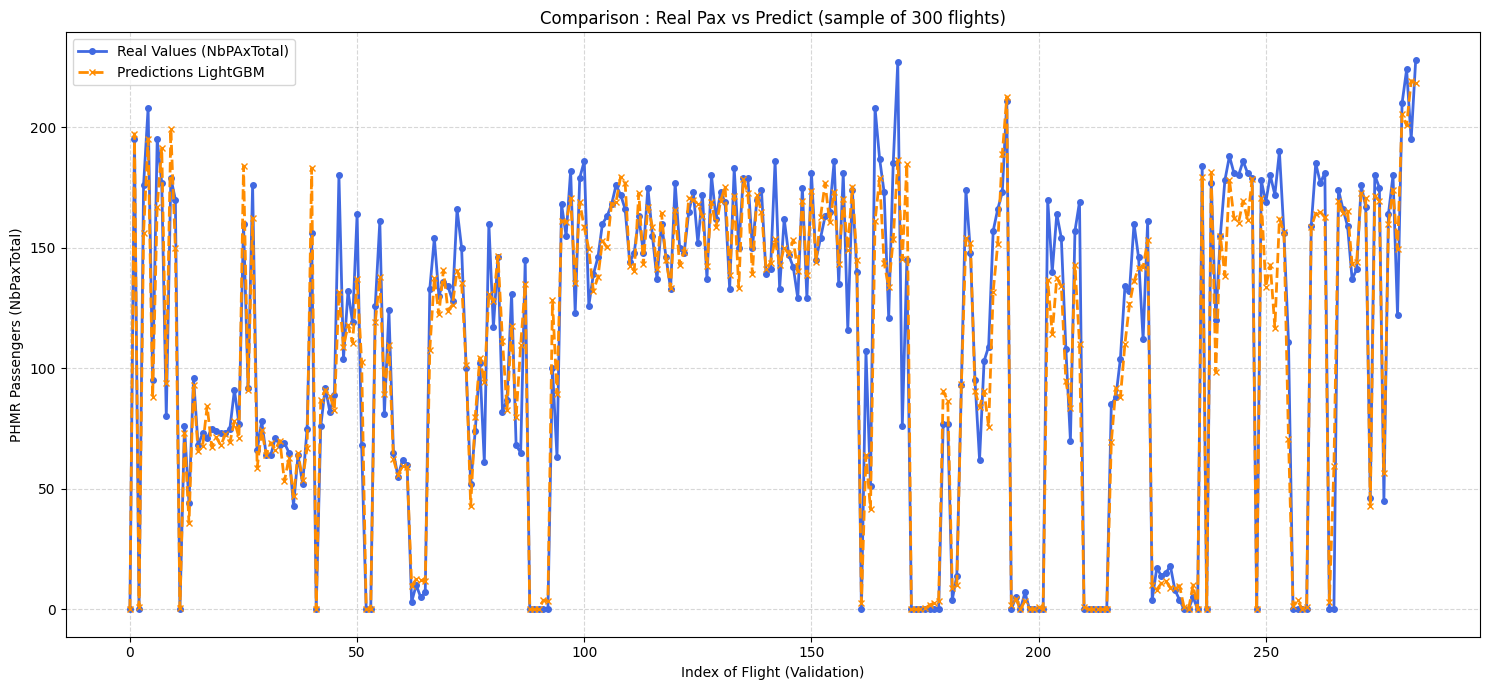

In [25]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Real Values (NbPAxTotal)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real Pax vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (NbPaxTotal)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Prediction VS Reality

The global accuracy can be noticed. The model is not perfect, but it predict the global trend and some outliers. It underestimate the majority of points and have difficulties to predict empty flights (NbPaxTotal = 0).

The predictions for the 'NbPaxTotal' variable are visually good.

#### 3. TOP 10 Errors

In [26]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[0]] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[0], 
               "Predicted_NbPax", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_NbPax'] = display_df['Predicted_NbPax'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[0]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,NbPaxTotal,Predicted_NbPax,NbOfSeats,Abs_Error
219682,EZY02432,2026-03-27 21:30:00,76.000000,145.200000,186.000000,69.200000
336808,VLJ00051,2026-03-27 18:35:00,0.000000,59.300000,50.000000,59.300000
267067,SEH00925,2026-03-27 19:30:00,169.000000,110.300000,180.000000,58.700000
327953,TVF07313,2026-03-27 22:15:00,172.000000,116.900000,189.000000,55.100000
82616,AUA00353,2026-03-27 12:05:00,180.000000,131.800000,180.000000,48.200000
219676,EZY08397,2026-03-27 10:20:00,208.000000,161.000000,235.000000,47.000000
135829,DLH01079,2026-03-27 19:00:00,65.000000,109.600000,138.000000,44.600000
213527,EWG09412,2026-03-27 20:00:00,107.000000,63.800000,186.000000,43.200000
219681,EZY08434,2026-03-27 20:50:00,227.000000,186.200000,235.000000,40.800000
327956,TVF07329,2026-03-27 22:50:00,111.000000,70.600000,189.000000,40.400000


#### Top 10 errors analysis:

There is no clrear explaination for those 10 errors. It semmes that it is just overestimation or underestimation of number of passenger. The only exception here is the flight 'VLJ00051' with 0 passengers. This is a business flight, which is a statistical execption in our dataset that can maybe explain the bad prediction. Note that for business flight, the number of pax may stay private. 

### PHMR

#### 1. Feature importance

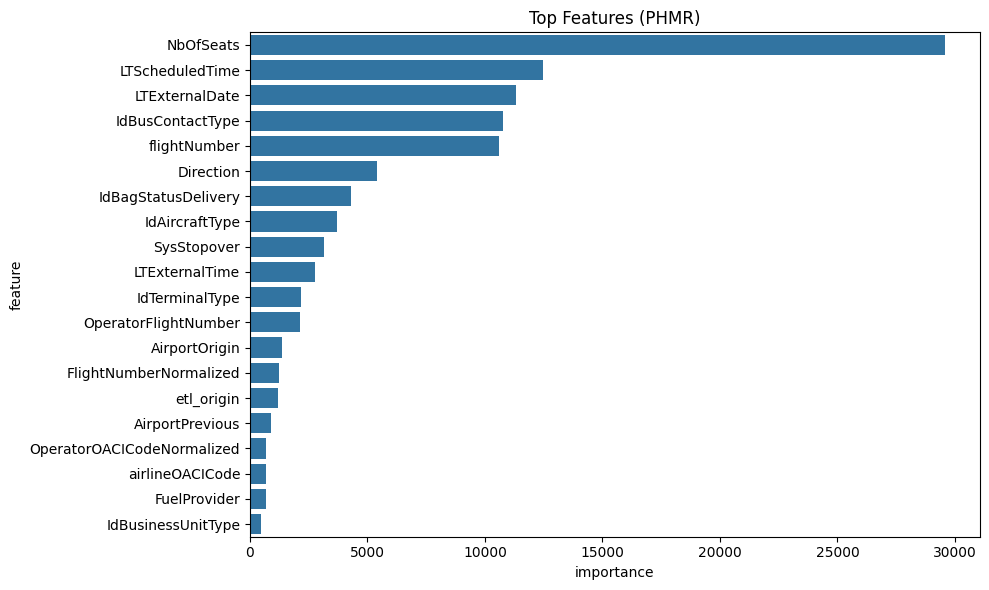

In [17]:
importance = pd.DataFrame({
    "feature": X_train_PHMR.columns,
    "importance": model_PHMR.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_PHMR.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (PHMR)")
plt.tight_layout()
plt.show()

For PHMR, there is no additional features. The observations are the same: the most important variables are those which can lead to flight re-identification. The only exception here is the feature 'NbOfSeats', which is the most important variable of the model.

#### 2. Prediction VS Reality

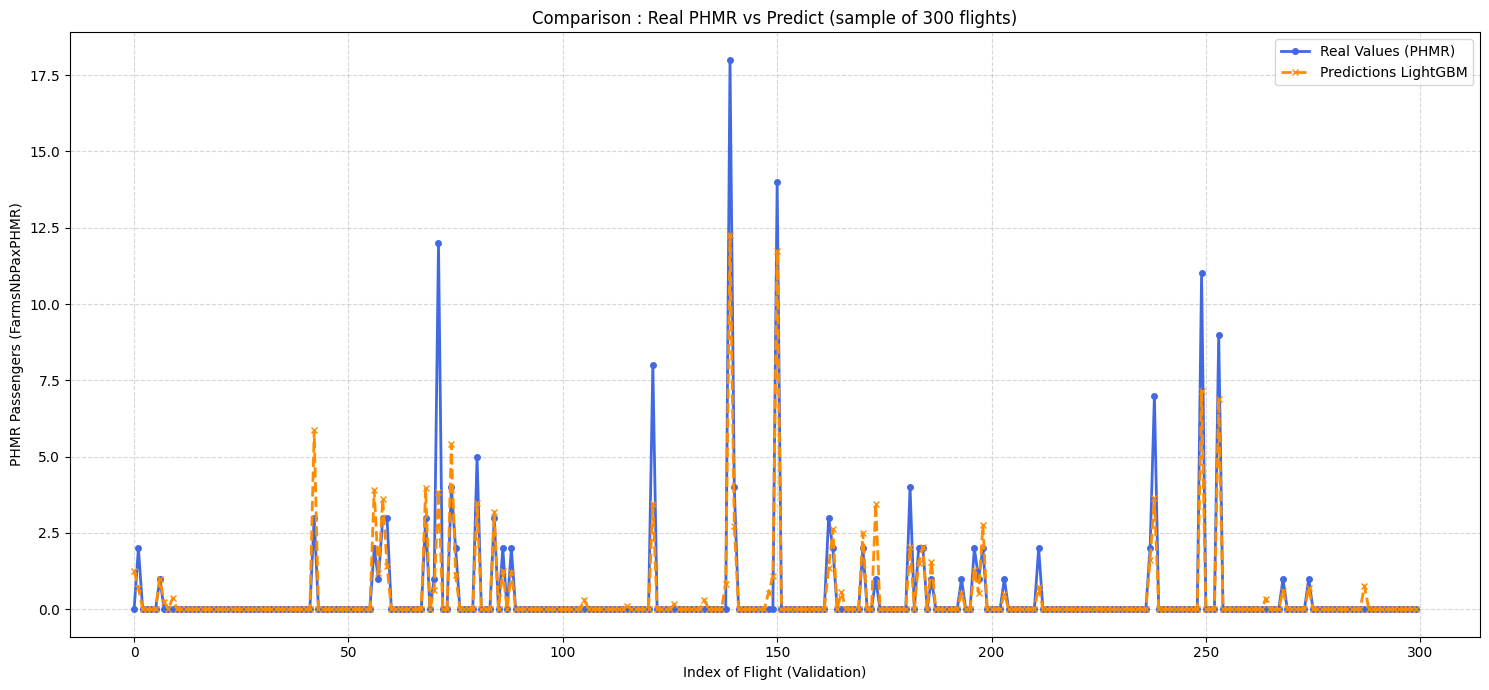

In [18]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid_PHMR.values[:n_sample], label='Real Values (PHMR)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions_PHMR[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real PHMR vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (FarmsNbPaxPHMR)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The preidction of PHMR Pax are less accurate than the number of pax predictions. It can be explained by the irregularity of the original distribution and the fact that PHMR are exceptional regarding to statistics. The associated model is then less efficients, because it is harder to predict irregular and exceptional behaviors.

#### 3. TOP 10 Errors

In [19]:
analysis_df = valid_df_PHMR.copy()
analysis_df['Predicted_PHMR'] = predictions_PHMR
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[1]] - analysis_df['Predicted_PHMR'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[1], 
               "Predicted_PHMR", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_PHMR'] = display_df['Predicted_PHMR'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[1]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,FarmsNbPaxPHMR,Predicted_PHMR,NbOfSeats,Abs_Error
55338,TVF08776,2026-03-30 06:00:00,15.000000,5.500000,189.000000,9.500000
55193,PGT01142,2026-03-30 14:40:00,12.000000,3.500000,239.000000,8.500000
54858,DAH01033,2026-03-31 17:55:00,12.000000,3.800000,144.000000,8.200000
55240,TVF07308,2026-03-30 11:55:00,10.000000,3.700000,189.000000,6.300000
54926,DAH01081,2026-03-31 13:35:00,18.000000,12.300000,162.000000,5.700000
55218,DAH01155,2026-03-30 12:45:00,18.000000,12.700000,148.000000,5.300000
55266,THY01808,2026-03-30 10:25:00,8.000000,2.800000,190.000000,5.200000
54908,PGT01142,2026-03-31 14:40:00,8.000000,3.500000,239.000000,4.500000
55153,DAH01154,2026-03-30 17:15:00,8.000000,3.600000,148.000000,4.400000
55036,TVF08776,2026-03-31 06:35:00,11.000000,7.100000,189.000000,3.900000


Due to the statistical particularity of PHMR Pax distribution, it is difficult to have good performances to predict the number of PHMR pax. Those error can be explain by an underestimation of irregularities and unexpected number of PHMR pax. 